[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ridatadiscoverycenter/riddc-jbook/blob/feature-mayas-notebook/riddc/notebooks/fox-kemper/Modeling_river_runoff_using_precipitation_data_in_Narragansett_Bay.ipynb)


**Introduction**

In this study, we model river runoff into Narragansett Bay and nearby waterways from gridded weather model precipitation data from the North American Mesoscale Model (NAMM) from 2006-2022. This model would allow us to approximate river flow projections based on precipitation projections, based on approximating the present day hydrological relationship between both. We approximate each major river basin emptying into the bay as a collection of grid cells of NAMM precipitation and sum the precipitation into each river basin. The precipitation data within each basin was compared against the respective river gauge data from the United States Geological Survey (USGS), using a simple cumulative time-lagged correlation approach. This comparison results in a simple model of river runoff in the bay that approximates runoff as the accumulated precipitation data weighted with an exponentially decreasing contribution with respect to time. This model explains a large fraction of the rivers’ flow and variability. 

**The Narragansett Bay**

The Narragansett Bay is an estuary in Rhode Island with multiple major river basins. The river basins we used in our model are shown in the map below and each star represents the location of the corresponding river gauge.  
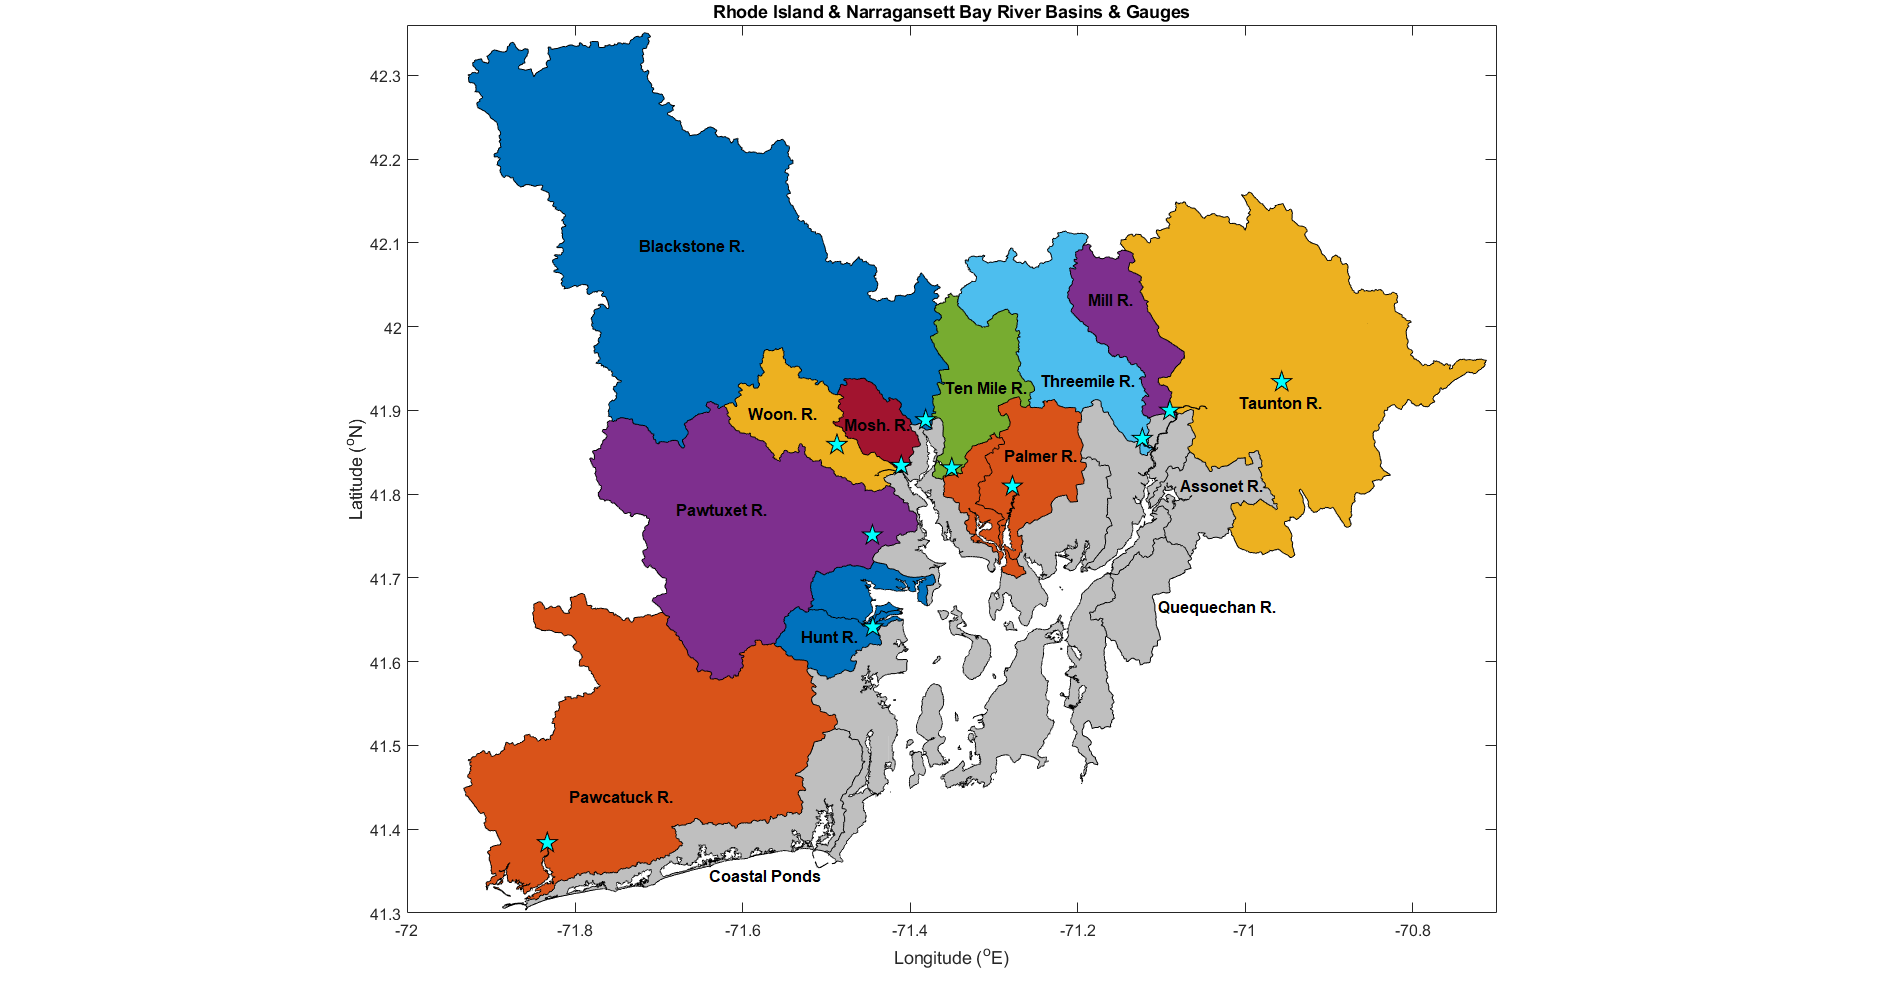
This map was created by Dr. Arin Nelson.

- We superimposed the precipitation grid cells on top of the map to determine which precipitation grid cell corresponds to which river basin. 
- We did not divide grid cells i.e. if over half of a grid cell was within one river basin, we counted that as the entire grid cell belonging to that river basin.
To process the precipitation data, we can use the following function.

In [63]:
# function that takes in a precipitation netcdf file and returns an xarray of gridded precip data for every three hours
def data_process(file_path,grid_data,year,month,day):
    
     
    # making array of hours that we have precip data for
    date_array = [None] * 9
    hour = 0
    for x in range(0,8):
        date_array[x] = [datetime(year,month,day,hour)]
        hour = hour + 3
    
    date_array[8] = [date_array[7][0] + timedelta(hours = 3)]
    
    # extracting lon and lat data from grid file
    grid = xr.open_dataset(grid_data)
    lon = grid['lon']
    lat = grid['lat']
    
    # reading in precip data
    ds = xr.open_dataset(file_path, decode_times=False)
    #print(ds)
    
    # determining if precipitation units are 'Total precipitation (3_Hour Accumulation) @ Ground or water surface'
    # or 'Total precipitation (Mixed_intervals Accumulation) @ Ground or water surface'. This code is assuming that
    # the precipitaiton is 3_hour accumulation so if it's mixed_intervals accumulation, this code will not know how
    # to process that
    #if chr(ds['rain_type'][23][1][0]) != 'H':
    #    print(file + 'precip units are weird')
    
    if year < 2019:
        rain_0 = ds['rain'][0,0,:,:]/(3*86400)
        rain_0 = rain_0.expand_dims(['time'],2)

        rain_6 = ds['rain'][0,1,:,:]/(3*86400)
        rain_6 = rain_6.expand_dims(['time'],2)

        rain_12 = ds['rain'][0,2,:,:]/(3*86400)
        rain_12 = rain_12.expand_dims(['time'],2)

        rain_18 = ds['rain'][0,3,:,:]/(3*86400)
        rain_18 = rain_18.expand_dims(['time'],2)

        rain_3 = ds['rain'][1,0,:,:]/(3*86400)
        rain_3 = rain_3.expand_dims(['time'],2)

        rain_9 = ds['rain'][1,1,:,:]/(3*86400)
        rain_9 = rain_9.expand_dims(['time'],2)

        rain_15 = ds['rain'][1,2,:,:]/(3*86400)
        rain_15 = rain_15.expand_dims(['time'],2)

        rain_21 = ds['rain'][1,3,:,:]/(3*86400)
        rain_21 = rain_21.expand_dims(['time'],2)
    else:
        #try:
        rain_6 = ds['rain'][4,0,:,:]/(3*86400)
        rain_6 = rain_6.expand_dims(['time'],2)
        #print(rain_6)

        rain_12 = ds['rain'][4,1,:,:]/(3*86400)
        rain_12 = rain_12.expand_dims(['time'],2)

        rain_18 = ds['rain'][4,2,:,:]/(3*86400)
        rain_18 = rain_18.expand_dims(['time'],2)

        rain_24 = ds['rain'][4,3,:,:]/(3*86400)
        rain_24 = rain_24.expand_dims(['time'],2)

        rain_3 = ds['rain'][3,0,:,:]/(3*86400)
        rain_3 = rain_3.expand_dims(['time'],2)

        rain_9 = ds['rain'][3,1,:,:]/(3*86400)
        rain_9 = rain_9.expand_dims(['time'],2)

        rain_15 = ds['rain'][3,2,:,:]/(3*86400)
        rain_15 = rain_15.expand_dims(['time'],2)

        rain_21 = ds['rain'][3,3,:,:]/(3*86400)
        rain_21 = rain_21.expand_dims(['time'],2)
        #except:
     

    ds_3 = xr.Dataset(
        {'rain': (['x','y','time'], rain_3.data)},
        coords={'lon': (['x','y'], lon.data),
            'lat': (['x','y'], lat.data),
            'time': (['time'], date_array[1])},
    )
    ds_3.attrs['units'] = 'mm/s' # i.e. kg/(m^2*s)
    
    ds_6 = xr.Dataset(
        {'rain': (['x','y','time'], rain_6.data)},
        coords={'lon': (['x','y'], lon.data),
            'lat': (['x','y'], lat.data),
            'time': (['time'], date_array[2])},
    )
    ds_6.attrs['units'] = 'mm/s' 
    
    ds_9 = xr.Dataset(
        {'rain': (['x','y','time'], rain_9.data)},
        coords={'lon': (['x','y'], lon.data),
            'lat': (['x','y'], lat.data),
            'time': (['time'], date_array[3])},
    )
    ds_9.attrs['units'] = 'mm/s'
    
    ds_12 = xr.Dataset(
        {'rain': (['x','y','time'], rain_12.data)},
        coords={'lon': (['x','y'], lon.data),
            'lat': (['x','y'], lat.data),
            'time': (['time'], date_array[4])},
    )
    ds_12.attrs['units'] = 'mm/s'

    ds_15 = xr.Dataset(
        {'rain': (['x','y','time'], rain_15.data)},
        coords={'lon': (['x','y'], lon.data),
            'lat': (['x','y'], lat.data),
            'time': (['time'], date_array[5])},
    )
    ds_15.attrs['units'] = 'mm/s'
    
    ds_18 = xr.Dataset(
        {'rain': (['x','y','time'], rain_18.data)},
        coords={'lon': (['x','y'], lon.data),
            'lat': (['x','y'], lat.data),
            'time': (['time'], date_array[6])},
    )
    ds_18.attrs['units'] = 'mm/s'
    
    ds_21 = xr.Dataset(
        {'rain': (['x','y','time'], rain_21.data)},
        coords={'lon': (['x','y'], lon.data),
            'lat': (['x','y'], lat.data),
            'time': (['time'], date_array[7])},
    )
    ds_21.attrs['units'] = 'mm/s'
    
    if year < 2019:
        ds_0 = xr.Dataset(
            {'rain': (['x','y','time'], rain_0.data)},
            coords={'lon': (['x','y'], lon.data),
                'lat': (['x','y'], lat.data),
                'time': (['time'], date_array[0])},
        )
        ds_0.attrs['units'] = 'mm/s'
        # combining each three hour precip xarray into one
        daily_precip = xr.combine_by_coords([ds_0, ds_3, ds_6, ds_9, ds_12, ds_15, ds_18, ds_21])
    else:
        ds_24 = xr.Dataset(
            {'rain': (['x','y','time'], rain_24.data)},
            coords={'lon': (['x','y'], lon.data),
                'lat': (['x','y'], lat.data),
                'time': (['time'], date_array[8])},
        )
        ds_24.attrs['units'] = 'mm/s'
        # combining each three hour precip xarray into one
        daily_precip = xr.combine_by_coords([ds_3, ds_6, ds_9, ds_12, ds_15, ds_18, ds_21, ds_24])

    return daily_precip

To superimpose the precipitation grid cells on top of Narragansett Bay, we first have to import geopandas. We can then use the following code. Note that this code creates a map of Narragansett Bay that only includes the major river basins. The smaller river basins in the bay are not included, however, since the precipitation grid cells are relatively big, it is easy to estimate which grid cells belong to which river basin.

In [ ]:
import geopandas as gp
from datetime import datetime
from datetime import timedelta
import xarray as xr
import matplotlib.pyplot as plt

In [ ]:
import os
import wget
if os.getenv("COLAB_RELEASE_TAG"):
    # Running in G-COLLAB
    !npx degit ridatadiscoverycenter/riddc-jbook/notebooks_data#main notebooks_data
    !npx degit ridatadiscoverycenter/riddc-jbook/test_data#main test_data
    !mkdir "./plots"
    !mkdir "./plots/tide_plots"
    raw_data_dir = "./notebooks_data/"
    test_data_dir = "./test_data/"
    plots_dir = "./plots/"
else:
    # NOT Running in G-COLLAB
    import urllib.request
    from pathlib import Path
    from zipfile import ZipFile
    ## Download large zip file
    url = "https://github.com/ridatadiscoverycenter/riddc-jbook-data/releases/download/v0.1.0/modeling_river_runoff_using_precipitation_data_in_narragansett_bay.zip"
    path = Path("../../../notebooks_data/modeling_river_runoff_using_precipitation_data_in_narragansett_bay.zip")
    resultFilePath, responseHeaders = urllib.request.urlretrieve(url,path) 
    ## Unzip File
    data_path = Path("../../../notebooks_data/")
    with ZipFile(path, 'r') as zObject:
        zObject.extractall( path= data_path)
    zObject.close()
    ## assign path 
    raw_data_path = data_path / "modeling_river_runoff_using_precipitation_data_in_narragansett_bay/"
    print(raw_data_path)

In [ ]:
# reading in the basins of the Narragansett Bay
river_basins_huc12 = gp.read_file(raw_data_path / 'river_basins/BASINS_NBEP2017.shp')
river_basins_huc12.plot(column='Basins')

# parse date from file name
file_name = 'rain_2006_01_11.nc'
year = int(file_name[5:9])
if file_name[10] == '0':
    month = int(file_name[11])
else:
     month = int(file_name[10:12])
if file_name[13] == '0':
    day = int(file_name[14])
else:
    day = int(file_name[13:15])

grid_data = raw_data_path / 'precipitation_data/namanl_grid-Copy1.nc'
precipitation_data = raw_data_path / 'precipitation_data/rain_2006_01_11.nc'
# cleaning up the precipitation data
ds = data_process(precipitation_data,grid_data,year,month,day)

# extracting longitude and latitude data from the precipitation data
lon = ds['lon'][15:25,16:25]
lat = ds['lat'][15:25,16:25]
rain = ds['rain'][15:25,16:25,0]

# plotting precipitation data on top of Narragansett Bay
fig, ax = plt.subplots()
ax.set_aspect('equal')
ax.pcolormesh(lon,lat,rain,edgecolors='white', cmap = 'viridis')#,label='s')#,transform=rotated_pole)
river_basins_huc12.plot(ax=ax, column='Basins', facecolor="none", edgecolor="yellow")
plt.xlabel('Longitude(E)')
plt.ylabel('Latitude(N)')
plt.title('Precipitation Grid on Narragansett Bay')

**Building the Model**

To calculate the river runoff at a certain time point, we summed the previous two weeks of precipitation data for that corresponding river basin according to a decay parameter, λ, between 0 and 1. Since our precipitation data was recorded every three hours, the modeled runoff at a certain time is equal to λ multiplied by the precipitation datapoint three hours earlier added with λ2 multiplied by the precipitation datapoint three hours before that added with λ3 multiplied by the precipitation datapoint three hours before that and so on until we have added all of the precipitation data for the previous two weeks. To do this, we first have to import the following packages:

In [65]:
import netCDF4 as nc
import numpy as np
import csv
import math
import xarray as xr
import datetime
from datetime import timedelta
from datetime import datetime
import matplotlib.pyplot as plt
from scipy.io import netcdf
from scipy.interpolate import griddata
import pandas as pd
from scipy.stats import linregress
from matplotlib import figure

These are the functions that you will need to use to process the precipitation data and calculate our approximated river runoff:

In [69]:
# function that processes and merges precip data from one date to another
# returns data with precip units of m^3/s
# start_date and end_date should be datetime objects
grid_data = raw_data_path / 'precipitation_data/namanl_grid-Copy1.nc'
precipitation_data = raw_data_path / 'precipitation_data/'

def merge_precip_data(start_date, end_date):
    
    temp_start = start_date - timedelta(1)
    temp_end = end_date + timedelta(1)
    
    num_days = (temp_end - temp_start).days # total number of days that are being merged together
    
    processed_data = [None] * num_days # array that will contain all of the cleaned datasets for each day that will be merged
    date = temp_start
    for x in range(0, num_days):
        
        year = date.year
        month = date.month
        day = date.day
        
        # constructing name of file
        if len(str(month)) == 1:
            file_month = '0' + str(month)
        else:
            file_month = str(month)
        if len(str(day)) == 1:
            file_day = '0' + str(day)
        else:
            file_day = str(day)
        precipitation_date = 'rain_' + str(year) + '_' + file_month + '_' + file_day + '.nc'
        file_name = precipitation_data / precipitation_date
                        
        try:
            clean_data = data_process(file_name,grid_data,year,month,day) # converts precip to units of mm/s
            #print(clean_data)
        except:
            print (file_name + ' does not have data')
            pass
        
        #print(processed_data[x])
        
        processed_data[x] = sum_riverbasins(clean_data) # converts precip to units of m^3/s
        
        date = date + timedelta(1)
    
    merged_data = pd.concat(processed_data)
    
    for x in range(0,16):
        if merged_data.index[0] == start_date:
            break
        else:
            merged_data = merged_data.drop(merged_data.index[0])
            
    for x in range(0,16):
        if merged_data.index[len(merged_data)-1] == end_date: # len(merged_data)-1 refers to index of last row
            break
        else:
            merged_data = merged_data.drop(merged_data.index[len(merged_data)-1])
            
    return merged_data

# function that takes in an xarray dataset of one day precip and takes the precip grid cells in each river basin and puts them 
# in one array and then sums each element in every array up to determine total precip in one river basin
# function returns a pandas dataframe of the precipitation within each river basin in one day
# units of precip are: m^3/(s)

def sum_riverbasins(ds):
    
    # making array of hours that we have precip data for
    date_array = [None] * 8
    try:
        for x in range(0,8):
            date_array[x] = ds['time'].values[x]
    except:
        return

    daily_basin_precip = [None]*8
    
    for x in range(0,8):
        blackstone_array = np.concatenate((ds['rain'][24:25,16:18,x].to_numpy(),ds['rain'][23:24,17:19,x].to_numpy(),
                                           ds['rain'][22:23,17:20,x].to_numpy(), ds['rain'][21:22,18:19,x].to_numpy()), axis = 1)
        blackstone_precip = np.sum(blackstone_array) * 12.19058**2 * 10**3 # multiplying by area of each grid cell
        # original precip units are mm/s but we are now converting to m^3/s
        # grid cell dimensions are 12.19058 km by 12.19058 km

        pawtuxet_array = np.concatenate((ds['rain'][20:21,18:20,x].to_numpy(), ds['rain'][19:20,18:20,x].to_numpy(),
                                         ds['rain'][18:19,19:20,x].to_numpy()), axis = 1)
        pawtuxet_precip = np.sum(pawtuxet_array) * 12.19058**2 * 10**3

        pawcatuck_array = np.concatenate((ds['rain'][18:19,18:19,x].to_numpy(), ds['rain'][17:18,18:20,x].to_numpy(),
                                         ds['rain'][16:17,17:20,x].to_numpy()), axis = 1)
        pawcatuck_precip = np.sum(pawcatuck_array) * 12.19058**2 * 10**3

        woon_array = ds['rain'][21:22,19:20,x].to_numpy()
        woon_precip = np.sum(woon_array) * 12.19058**2 * 10**3

        hunt_array = ds['rain'][19:20,20:21,x].to_numpy()
        hunt_precip = np.sum(hunt_array) * 12.19058**2 * 10**3

        mosh_array = ds['rain'][20:21,20:21,x].to_numpy()
        mosh_precip = np.sum(mosh_array) * 12.19058**2 * 10**3

        tenmile_array = np.concatenate((ds['rain'][22:23,20:21,x].to_numpy(), ds['rain'][21:22,20:21,x].to_numpy()), axis = 1)
        tenmile_precip = np.sum(tenmile_array) * 12.19058**2 * 10**3

        threemile_array = np.concatenate((ds['rain'][22:23,21:22,x].to_numpy(), ds['rain'][21:22,22:23,x].to_numpy()), axis = 1)
        threemile_precip = np.sum(threemile_array) * 12.19058**2 * 10**3

        palmer_array = np.concatenate((ds['rain'][21:22,21:22,x].to_numpy(), ds['rain'][20:21,21:22,x].to_numpy()), axis = 1)
        palmer_precip = np.sum(palmer_array) * 12.19058**2 * 10**3

        mill_array = ds['rain'][22:23,22:23,x].to_numpy()
        mill_precip = np.sum(mill_array) * 12.19058**2 * 10**3

        taunton_array = np.concatenate((ds['rain'][23:24,22:24,x].to_numpy(),ds['rain'][22:23,23:25,x].to_numpy(),
                                       ds['rain'][21:22,23:24,x].to_numpy(), ds['rain'][20:21,23:24,x].to_numpy()), axis = 1)
        taunton_precip = np.sum(taunton_array) * 12.19058**2 * 10**3
        
        time = [date_array[x]]
        
        threehr_basin_precip = [{'blackstone': blackstone_precip, 'pawtuxet': pawtuxet_precip, 'pawcatuck': pawcatuck_precip,
                       'woon': woon_precip, 'hunt': hunt_precip, 'mosh': mosh_precip, 'tenmile': tenmile_precip,
                       'threemile': threemile_precip, 'palmer': palmer_precip, 'mill': mill_precip, 'taunton': taunton_precip}]

        daily_basin_precip[x] = pd.DataFrame(threehr_basin_precip, index = time)
        
    daily_basin_precip_df = pd.concat([daily_basin_precip[0], daily_basin_precip[1], daily_basin_precip[2], daily_basin_precip[3], 
               daily_basin_precip[4], daily_basin_precip[5], daily_basin_precip[6], daily_basin_precip[7]])
    
    return daily_basin_precip_df

# takes in a dataframe and parameter value and calculates a weighted sum that exponentially decreases(by param) with respect to time
def approx_one_datapoint_river_runoff(file, param):
    sum = 0
    c = param # parameter value
    current_index = len(file) - 1 # index number of last row in file
    for x in range(0, len(file)):
        if np.isnan(file.iloc[current_index]):
            file.iloc[current_index] = 0
        #print(file.iloc[current_index])
        sum = file.iloc[current_index] * c**(x+1) + sum
        current_index = current_index - 1
    return sum

# function that calculates an approximated river runoff from one date to another
# start_date, end_date: start and end date of the river runoff approximation that you want to be calculated
# start_date and end date should be in the form: year_month_day (e.g. January 1, 2006 = '2006_01_01')

def approx_river_runoff(basin, start_date, end_date, param):
    
    # converting start date and end date time from type string to type datetime
    start_year = start_date[0:4]
    if start_date[5] == '0':
        start_month = start_date[6]
    else:
        start_month = start_date[5:7]
    if start_date[8] == '0':
        start_day = start_date[9]
    else:
        start_day = start_date[8:10]

    end_year = end_date[0:4]
    if end_date[5] == '0':
        end_month = end_date[6]
    else:
        end_month = end_date[5:7]
    if end_date[8] == '0':
        end_day = end_date[9]
    else:
        end_day = end_date[8:10]
    start_datetime = datetime(int(start_year), int(start_month), int(start_day), 0)
    end_datetime = datetime(int(end_year), int(end_month), int(end_day), 21)

    # determining what precipitation dates will be needed to calculate river runoff
    precip_start = start_datetime - timedelta(14)
    precip_end = end_datetime
    num_datapoints = (end_datetime - start_datetime).days * 8 # multiply by 8 because there are 8 datapoints taken each day
    all_precip = merge_precip_data(precip_start, precip_end)
    basin_precip = all_precip[basin]
    #print(len(basin_precip))
    runoff_approx = [None] * num_datapoints
    date_array = [None] * num_datapoints # array that will hold all of the dates of runoff that we are approximating
    current_date = start_datetime
    
    # calculating river runoff and keeping track of the dates of the calculated river runoff
    for x in range(0,num_datapoints):
        #print(x+14*8)
        #print(basin_precip.iloc[x:x+14*8])
        runoff_approx[x] = approx_one_datapoint_river_runoff(basin_precip.iloc[x:x+14*8], param) #14*8 is the index of the datapoint 14 days after x
        #print('sum: ')
        #print(runoff_approx[x])
        date_array[x] = current_date
        #print(current_date)
        current_date = current_date + timedelta(hours = 3)
    
    #print(runoff_approx)
    #print(date_array)
    data = {'datetime': date_array,
            'runoff_approx': runoff_approx}
        #print(data)
  
    runoff_approx_df = pd.DataFrame(data)
    
    return runoff_approx_df

To use these functions to calculate the approximated river runoff for one river basin for a certain point in time, we will use the function, approx_river_runoff. This function calls the other functions listed above and will output a dataframe of the calculated river runoff for a certain amount of time. The syntax of the function is: approx_river_runoff(river basin name, start date, end date, parameter value). When inputting the river basin name into the function, they must be in the following forms:
- 'taunton'
- 'threemile'
- 'tenmile'
- 'blackstone'
- 'mosh'
- 'woon'
- 'pawtuxet'
- 'hunt'
- 'pawcatuck'
The start and end date must be in the form year_month_day(xxxx_xx_xx) with leading zeros in front of month and day if necessary. For instance, June 20, 2020 should be inputted as 2020_06_20. The parameter value should be a value between 0 and 1. I found that 0.98 worked well for the years 2019 and 2020 but it may be slightly different for other years. In the code below, we are using the function to calculate the river runoff for the Three Mile river basin between the dates June 6, 2020 and September 9, 2022 and the dates December 31, 2019 and March 3, 2019 both with a parameter value of 0.98. The code usually takes several minutes to run but will take longer if you input a longer time window.

In [70]:
# approx_river_runoff(river basin name, start date, end date, parameter value)
approx_summer = approx_river_runoff('threemile', '2020_06_20', '2020_09_22', 0.98)
approx_winter = approx_river_runoff('threemile', '2019_12_31', '2020_03_19', 0.98)

To plot the modeled river runoff with respect to time, we can use the following piece of code.

In [ ]:
ax = approx_summer.plot(x='datetime', y='runoff_approx', title='Modeled Summer Runoff')
ax.set_xlabel('Date')
ax.set_ylabel('Runoff (m^3/s)')
ax = approx_winter.plot(x='datetime', y='runoff_approx', title='Modeled Winter Runoff')
ax.set_xlabel('Date')
ax.set_ylabel('Runoff (m^3/s)')

To determine how accurate our model is, we can compare it against observed river gage data from the USGS. We can use the function streamflow_year_month to process the USGS river gage data. Note that this function takes in a parameter labeled as header_row_number. header_row_number represents the line number in the csv file where the data actually begins. The names of the river gage csv files are numbered and are the following:

In [72]:
taunton = '01108000.csv' # header = 29
threemile = '01109060.csv' # header = 29
tenmile = '01109403.csv' # header = 29
blackstone1 = '01112500.csv' # header = 31 # Woonsocket, RI (this one is farther inland)
blackstone2 = '01113895.csv' # header = 31 # Roosevelt St. at Pawtucket, RI (this one is closer to the bay)
moshassuck = '01114000.csv' # header = 29
woonasquatucket = '01114500.csv' # header = 30
pawtuxet = '1116500.csv'# header = 29
hunt = '01117000.csv' # header = 29
pawcatuck1 = '01117500.csv' # Wood River Junction, RI (this one is further inland)
pawcatuck2 = '01118500.csv' # header = 29 # Westerly, RI (this one is closer to the bay)

In [81]:
# function that takes in streamflow file, start date, end date, and the line number of the header of the streamflow file and 
# parses the streamflow data to be every three hours and between the start and end date
# start_date and end date should be in the form: month/day/year with no leading zeros(e.g. January 1, 2006 = '1/1/2006')

def streamflow_year_month(file, start_date, end_date, header_row_number):
    streamflow_file =  raw_data_path / ('rivergage_data/'+file)
    df = pd.read_csv(streamflow_file, header = header_row_number)
    
    # deleting empty/NaN rows
    for x in range(0,df.shape[0]):
        try:
            float(df['streamflow (ft^3/s)'][x])
        except ValueError:
            df = df.drop(x) 
        
    df['streamflow (ft^3/s)'] = pd.Series(df['streamflow (ft^3/s)'], dtype='float') # converting streamflow data to type float
    
    start_index = df.index[df['datetime'] == start_date + ' 0:00']
    end_index = df.index[df['datetime'] == end_date + ' 21:00']
    
    parsed_data = df.iloc[start_index[0]:end_index[0]+1]
    
    # creating new dataframe that only has data from 0:00, 3:00, 6:00, 9:00, 12:00, 15:00, 18:00, 21:00, 24:00
    num_of_rows_threehr_df = math.floor((end_index[0]-start_index[0]+1)/12)
    threehr_df = pd.DataFrame()
    threehr_list = []
    for x in range(0,end_index[0]-start_index[0]+1):  
        one_datapoint = parsed_data.iloc[x]
        if ' 0:00' in one_datapoint['datetime']:
            threehr_list.append(one_datapoint)
        elif ' 3:00' in one_datapoint['datetime']:
            threehr_list.append(one_datapoint)
        elif ' 6:00' in one_datapoint['datetime']:
            threehr_list.append(one_datapoint)
        elif ' 9:00' in one_datapoint['datetime']:
            threehr_list.append(one_datapoint)
        elif '12:00' in one_datapoint['datetime']:
            threehr_list.append(one_datapoint)
        elif '15:00' in one_datapoint['datetime']:
            threehr_list.append(one_datapoint)
        elif '18:00' in one_datapoint['datetime']:
            threehr_list.append(one_datapoint)
        elif '21:00' in one_datapoint['datetime']:
            threehr_list.append(one_datapoint)
    threehr_df = pd.concat(threehr_list, axis = 1)
    threehr_df = threehr_df.transpose()

    # changing values in 'datetime' column to be of type datetime instead of string
    date_array = [None] * len(threehr_df)
    for x in range(0,len(threehr_df)):
        date = datetime.strptime(threehr_df['datetime'].iloc[x], '%m/%d/%Y %H:%M')
        date_array[x] = date    
    threehr_df['datetime'] = date_array
    
    # converting from ft^3/s to m^3/s
    threehr_df = threehr_df.rename(columns={'streamflow (ft^3/s)':'streamflow (m^3/s)'})
    threehr_df['streamflow (m^3/s)'] = threehr_df['streamflow (m^3/s)']*(.305**3)
    
    threehr_df['streamflow (m^3/s)'] = pd.to_numeric(threehr_df['streamflow (m^3/s)'])

    return threehr_df

To compare our modeled runoff against the observed runoff, we can create scatterplots with modeled runoff on one axis and observed runoff on another. The following piece of code calculates modeled runoff during winter 2019/2020 and summer 2020 and creates a scatter plot for each of the river basins. It uses a parameter value of 0.98 to calculate our modeled runoff. For each of the scatter plots, the code will divide the modeled runoff by the original slope of line of best fit so that that the printed scatter plot will have a line of best fit with a slope of 1. This code also keeps tracks of the original line of best fit slopes which can be later plotted and compared. This code will take a while to run.

In [ ]:
rivers = [taunton, threemile, tenmile, blackstone2, moshassuck, woonasquatucket, pawtuxet, hunt, pawcatuck2]
headers = [29, 29, 29, 31, 29, 30, 29, 29, 29]
basins = ['taunton', 'threemile', 'tenmile', 'blackstone', 'mosh', 'woon', 'pawtuxet', 'hunt', 'pawcatuck']

slopes = [0] * 9
for x in range(0,9):
    
    name = basins[x]
    print(name)
    summer_river_data = streamflow_year_month(rivers[x], '6/20/2020', '9/22/2020', headers[x])
    winter_river_data = streamflow_year_month(rivers[x], '12/31/2019', '3/19/2020', headers[x])
    approx_summer = approx_river_runoff(basins[x], '2020_06_20', '2020_09_22', 0.98)
    approx_winter = approx_river_runoff(basins[x], '2019_12_31', '2020_03_19', 0.98)
    
    combined_summer = pd.merge(approx_summer, summer_river_data, on='datetime')
    x_summer = combined_summer['streamflow (m^3/s)'].to_numpy()
    y_summer = combined_summer['runoff_approx'].to_numpy()
    fit_summer = np.polyfit(x_summer,y_summer,1)
    print('Original summer slope: ' + str(fit_summer[0]))
    combined_summer['runoff_approx'] = combined_summer['runoff_approx'] * 1/fit_summer[0]
    ax_summer = combined_summer.plot.scatter(x='streamflow (m^3/s)', y='runoff_approx', title = name + ' River: Observed vs. Model Runoff for 2020 Summer')
    ax_summer.set_xlabel('observed')
    ax_summer.set_ylabel('modeled')
    ax_summer.legend(['parameter=0.98'])
    plt.show()
    
    combined_winter = pd.merge(approx_winter, winter_river_data, on='datetime')
    x_winter = combined_winter['streamflow (m^3/s)'].to_numpy()
    y_winter = combined_winter['runoff_approx'].to_numpy()
    fit_winter = np.polyfit(x_winter,y_winter,1)
    print('Original winter slope: ' + str(fit_winter[0]))
    slopes[x] = fit_winter[0]
    combined_winter['runoff_approx'] = combined_winter['runoff_approx'] * 1/fit_winter[0]
    ax_winter = combined_winter.plot.scatter(x='streamflow (m^3/s)', y='runoff_approx', title= name + 'River: Observed vs. Model Runoff for 2019/2020 Winter')
    ax_winter.set_xlabel('observed')
    ax_winter.set_ylabel('modeled')
    ax_winter.legend(['parameter=0.98'])
    plt.plot()
    plt.show()
    
print(slopes)

The following section of code is an example of how to create a scatter plot for only one of the river basins and also adds a line of regression.

In [ ]:
summer_river_data = streamflow_year_month(threemile, '6/20/2020', '9/22/2020', 29)
approx_summer = approx_river_runoff('threemile', '2020_06_20', '2020_09_22', 0.98)

combined = pd.merge(approx_summer, summer_river_data, on='datetime')
x = combined['streamflow (m^3/s)'].to_numpy()
y = combined['runoff_approx'].to_numpy()
fit = np.polyfit(x,y,1)
print(fit)
combined['runoff_approx'] = combined['runoff_approx'] * 1/fit[0]

x_after = combined['streamflow (m^3/s)'].to_numpy()
y_after = combined['runoff_approx'].to_numpy()
fit_after = np.polyfit(x_after,y_after,1)
x_fit = np.linspace(0,6.1,1000)
y_fit = fit_after[0]*x_fit+fit_after[1]

markersize = [80] * len(x_after)
ax = combined.plot.scatter(x='streamflow (m^3/s)', y='runoff_approx', s=markersize)
ax.set_title('Three Mile River: Observed vs. Model Runoff, 2020 Summer', fontsize = 20)
regression = linregress(x_after, y_after)
rvalue = str(round(regression.rvalue, 2))
ax.plot(x_fit,y_fit, 'r')
ax.set_xlabel('observed', fontsize = 20)
ax.set_ylabel('modeled', fontsize = 20)
plt.rcParams["figure.figsize"] = (15,12)#plt.rcParamsDefault["figure.figsize"]
ax.legend(['decay parameter=0.98', 'R^2 value=' + rvalue], loc = 'lower right', prop={'size': 20})
plt.show()

To create a bar graph that compares all of the slopes of line of best fits for each of the river basins, we can use the following code.

In [ ]:
basin = ['Taunton', 'Three Mile', 'Ten Mile', 'Blackstone', 'Moshassuck', 'Woonasquatucket', 'Pawtuxet', 'Hunt', 'Pawcatuck']
data = {'River Basin': basin,
       'Slope': slopes}
df = pd.DataFrame(data)
ax = df.plot.barh(x = 'River Basin', y = 'Slope', title = 'Line of Best Fit Slopes for Observed vs. Modeled Runoff in 2019/2020 Winter', legend=False, fontsize = 20)
ax.set_ylabel('River Basin', fontsize = 20)
ax.set_xlabel('Slope', fontsize = 20)